# Sinusoid Regression: Kron Last Layer (Laplace) vs Bayesian-Torch BNNs, 5-Seed

Same head-to-head as the single-seed sinusoid comparison notebook (600/200/200/200 split) but averaged
over 5 random seeds. Checkpoints live in `sinusoid_comparison_5seed/`.

In [1]:
from pathlib import Path
import sys, os, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss
from scipy.stats import norm as _norm

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import (checkpoint_exists, load_checkpoint, save_checkpoint,
                    seed_everything, regression_metrics, combine_predictive_std,
                    load_sinusoid, bt_mc_forward, optimize_noise_std_bt,
                    get_sinusoid_mlp, la_predict, bt_predict, build_laplace_variant)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEEDS        = [711, 42, 123, 456, 789]
sigma_noise  = 0.3
num_mc_samples = 100
TRAIN_LO, TRAIN_HI = 0.0, 8.0

FIGURES_DIR     = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "sinusoid_comparison_5seed")
os.makedirs(CHECKPOINT_BASE, exist_ok=True)

plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "savefig.dpi": 150, "savefig.bbox": "tight"})
print(f"5-seed sinusoid comparison | seeds={SEEDS} | checkpoints -> {CHECKPOINT_BASE}")


Device: cuda
5-seed sinusoid comparison | seeds=[711, 42, 123, 456, 789] | checkpoints -> /u/halle/carg/home_at/Documents/BNNs/results/checkpoints/sinusoid_comparison_5seed


In [2]:
def plot_prediction(x_grid, f_mu, epistemic_std, aleatoric_std, title, ax,
                    X_train_np=None, y_train_np=None):
    epi = np.asarray(epistemic_std).ravel()
    total = combine_predictive_std(epi, float(aleatoric_std))
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.08)
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.08, label="OOD")
    ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
    if X_train_np is not None:
        ax.scatter(X_train_np, y_train_np, c="tab:blue", s=8, alpha=0.25, zorder=3, label="Train")
    ax.plot(x_grid, f_mu, color="tab:orange", lw=2, label="Mean")
    ax.fill_between(x_grid, f_mu-2*total, f_mu+2*total,
                    color="tab:orange", alpha=0.20, label="±2σ total")
    ax.fill_between(x_grid, f_mu-2*epi, f_mu+2*epi,
                    color="tab:purple", alpha=0.30, label="±2σ epistemic")
    ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title(title)
    ax.legend(loc="upper left", fontsize=7); ax.grid(True, alpha=0.3)

def build_bt(model_type, moped, seed, map_weights=None, moped_delta=0.5):
    net = get_sinusoid_mlp(seed)
    if moped and map_weights is not None:
        net.load_state_dict(map_weights)
    dnn_to_bnn(net, {
        "prior_mu": 0.0, "prior_sigma": 1.0,
        "posterior_mu_init": 0.0, "posterior_rho_init": -3.0,
        "type": model_type, "moped_enable": moped, "moped_delta": moped_delta,
    })
    net.model_type = model_type  # stashed for prediction dispatch (Flipout vs BBB) below
    return net

# ── Variant specs (unchanged from single-seed) ────────────────────────────────
la_variant_specs = [
    {"variant_name": "kron_last_layer_marglik",    "tune": "marglik",
     "subset": "last_layer", "hessian": "kron", "plot_title": "Kron / last layer / marglik"},
    {"variant_name": "kron_last_layer_gridsearch", "tune": "gridsearch",
     "subset": "last_layer", "hessian": "kron", "plot_title": "Kron / last layer / gridsearch"},
    {"variant_name": "kron_last_layer_adam_loop",  "tune": "adam_loop",
     "subset": "last_layer", "hessian": "kron", "plot_title": "Kron / last layer / adam loop"},
]

la_allweights_specs = [
    {"variant_name": "kron_all_marglik",    "subset": "all", "hessian": "kron",
     "tune": "marglik",    "plot_title": "Kron / all weights / marglik"},
    {"variant_name": "kron_all_gridsearch", "subset": "all", "hessian": "kron",
     "tune": "gridsearch", "plot_title": "Kron / all weights / gridsearch"},
    {"variant_name": "kron_all_adam_loop",  "subset": "all", "hessian": "kron",
     "tune": "adam_loop",  "plot_title": "Kron / all weights / adam loop"},
    {"variant_name": "full_all_gridsearch", "subset": "all", "hessian": "full",
     "tune": "gridsearch", "plot_title": "Full / all weights / gridsearch"},
]

bt_variant_specs = []
for model_type, short in [("Flipout", "flipout"), ("Reparameterization", "bbb")]:
    for moped in [False, True]:
        init = "moped" if moped else "scratch"
        bt_variant_specs.append({
            "variant_name": f"{short}_{init}",
            "model_type": model_type,
            "moped": moped,
            "epochs": 400 if moped else 1000,
            "plot_title": f"{'BBB' if short=='bbb' else 'Flipout'} / {init}",
        })

DELTA_VALUES = [0.05, 0.1, 0.2]
delta_variant_specs = []
for model_type, short in [("Flipout", "flipout"), ("Reparameterization", "bbb")]:
    for delta in DELTA_VALUES:
        delta_str = str(delta).replace(".", "")
        delta_variant_specs.append({
            "variant_name": f"{short}_moped_d{delta_str}",
            "model_type": model_type,
            "moped_delta": delta,
            "epochs": 400,
            "plot_title": f"{'BBB' if short=='bbb' else 'Flipout'} / moped / δ={delta}",
        })

all_la_specs = la_variant_specs + la_allweights_specs


In [3]:
all_seed_la_res    = {}   # {seed: {vname: res_dict}}
all_seed_bt_res   = {}   # {seed: {vname: res_dict}}
all_seed_delta_res = {}   # {seed: {vname: res_dict}}
all_seed_y_test    = {}   # {seed: {"id": y_test_id_np, "ood": y_test_ood_np}}

criterion = nn.MSELoss()
X_test_grid = torch.linspace(-5, 13, 500).unsqueeze(-1)
x_grid = X_test_grid.flatten().numpy()

for seed in SEEDS:
    print(f"\n{'='*60}\nSEED {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})\n{'='*60}")

    # ── Data (move everything to device) ──────────────────────────────────────
    d = load_sinusoid(n_data=600, sigma_noise=sigma_noise, batch_size=64, seed=seed,
                      device=device, n_val=200, n_test_id=200, n_test_ood=200)
    X_train      = d["X_train"].to(device)
    y_train      = d["y_train"].to(device)
    X_val        = d["X_val"].to(device)
    y_val        = d["y_val"].to(device)
    X_test_id    = d["X_test_id"].to(device)
    y_test_id    = d["y_test_id"].to(device)
    X_test_ood   = d["X_test_ood"].to(device)
    y_test_ood   = d["y_test_ood"].to(device)
    X_test_grid_dev = X_test_grid.to(device)
    train_loader_dev = d["train_loader"]
    val_loader_dev   = d["val_loader"]
    y_val_np      = y_val.cpu().flatten().numpy()
    y_test_id_np  = y_test_id.cpu().flatten().numpy()
    y_test_ood_np = y_test_ood.cpu().flatten().numpy()
    all_seed_y_test[seed] = {"id": y_test_id_np, "ood": y_test_ood_np}
    num_samp = len(X_train)

    # ── MAP ───────────────────────────────────────────────────────────────────
    map_ckpt  = os.path.join(CHECKPOINT_BASE, f"sinusoid_map_seed{seed}.pt")
    map_model = get_sinusoid_mlp(seed).to(device)
    if checkpoint_exists(map_ckpt):
        map_model.load_state_dict(load_checkpoint(map_ckpt, map_location=device)["model_state_dict"])
        print("  MAP: loaded")
    else:
        opt = optim.Adam(map_model.parameters(), lr=1e-2)
        t0 = time.time()
        for _ in range(2000):
            for xb, yb in train_loader_dev:
                opt.zero_grad(); criterion(map_model(xb), yb).backward(); opt.step()
        fit_time = time.time() - t0
        save_checkpoint({"model_state_dict": map_model.state_dict(), "fit_time": fit_time}, map_ckpt)
        print(f"  MAP: trained ({fit_time:.1f}s)")
    map_model.eval()
    map_weights = copy.deepcopy(map_model.state_dict())
    with torch.no_grad():
        map_resid_std = float((y_train - map_model(X_train)).std().item())

    # ── Helper: fit one Laplace variant ───────────────────────────────────────
    def _fit_laplace(spec, ckpt_prefix):
        vname   = spec["variant_name"]
        la_ckpt = os.path.join(CHECKPOINT_BASE, f"{ckpt_prefix}_seed{seed}.pt")
        la = build_laplace_variant(
            get_sinusoid_mlp(seed).to(device), map_model, spec, "regression",
            subset_key="subset", hessian_key="hessian")
        loaded = False; m = {}
        if checkpoint_exists(la_ckpt):
            p = load_checkpoint(la_ckpt)
            if isinstance(p, dict) and p.get("la") is not None:
                la = p["la"]; m = dict(p.get("metrics", {})); loaded = True
            elif isinstance(p, dict) and p.get("la_state_dict") is not None:
                la.load_state_dict(p["la_state_dict"])
                m = dict(p.get("metrics", {})); loaded = True
        if not loaded:
            t0 = time.time(); la.fit(train_loader_dev)
            m = {"Tune_Method": spec["tune"], "Fit_Time (s)": time.time() - t0}
            t1 = time.time()
            if spec["tune"] == "adam_loop":
                log_prior = torch.ones(1, requires_grad=True)
                log_sigma = torch.ones(1, requires_grad=True)
                hyp_opt = torch.optim.Adam([log_prior, log_sigma], lr=1e-1)
                for _ in range(1000):
                    hyp_opt.zero_grad()
                    (-la.log_marginal_likelihood(log_prior.exp(), log_sigma.exp())).backward()
                    hyp_opt.step()
                la.prior_precision = log_prior.exp().detach()
                la.sigma_noise = log_sigma.exp().detach()
            else:
                la.sigma_noise = torch.tensor(map_resid_std)
                if spec["tune"] == "marglik":
                    la.optimize_prior_precision(method="marglik")
                else:
                    la.optimize_prior_precision(method="gridsearch", val_loader=val_loader_dev)
            m["Tune_Time (s)"] = time.time() - t1
            m["Prior_Precision"] = float(np.atleast_1d(la.prior_precision.detach().cpu().numpy())[0])
            m["Sigma_Noise"] = float(la.sigma_noise.item())
            save_checkpoint({"la": la, "la_state_dict": la.state_dict(), "metrics": m}, la_ckpt)
        sigma = float(la.sigma_noise.item()); m["Sigma_Noise"] = sigma
        f_mu_g, epi_g   = la_predict(la, X_test_grid_dev)
        t_inf = time.time()
        mu_id,  epi_id  = la_predict(la, X_test_id)
        m["Inf_Time (s)"] = time.time() - t_inf
        mu_ood, epi_ood = la_predict(la, X_test_ood)
        total_id = combine_predictive_std(epi_id, sigma)
        m.update({"Mean_Epistemic_Std": float(np.mean(epi_id)),
                  "Mean_Aleatoric_Std": float(sigma),
                  "Mean_Total_Std": float(np.mean(total_id))})
        m.update(regression_metrics(y_test_id_np, mu_id, total_id))
        status = "loaded" if loaded else "fitted"
        print(f"  [{status}] {vname}: RMSE={m.get('RMSE',float('nan')):.4f}")
        return {"la": la, "f_mu": f_mu_g, "epi_std": epi_g, "sigma": sigma,
                "mu_id": mu_id, "epi_id": epi_id, "mu_ood": mu_ood, "epi_ood": epi_ood, "metrics": m}

    # ── Laplace last layer ────────────────────────────────────────────────────
    seed_la = {}
    for spec in la_variant_specs:
        seed_la[spec["variant_name"]] = _fit_laplace(spec, f"sinusoid_{spec['variant_name']}")

    # ── Laplace all weights ───────────────────────────────────────────────────
    for spec in la_allweights_specs:
        seed_la[spec["variant_name"]] = _fit_laplace(spec, f"sinusoid_la_{spec['variant_name']}")

    all_seed_la_res[seed] = seed_la

    # ── Helper: train one BT variant ──────────────────────────────────────────
    def _train_bt(spec, moped_delta=0.5):
        vname = spec["variant_name"]
        ckpt  = os.path.join(CHECKPOINT_BASE, f"sinusoid_{vname}_seed{seed}.pt")
        net   = build_bt(spec["model_type"], spec.get("moped", True),
                          seed=seed, map_weights=map_weights if spec.get("moped") else None,
                          moped_delta=moped_delta).to(device)
        m = {}; loaded = False
        if checkpoint_exists(ckpt):
            p = load_checkpoint(ckpt, map_location=device)
            if isinstance(p, dict) and "model_state_dict" in p:
                net.load_state_dict(p["model_state_dict"]); m = dict(p.get("metrics", {})); loaded = True
        if not loaded:
            seed_everything(seed)
            opt_b = optim.Adam(net.parameters(), lr=1e-3)
            patience, best_val, best_state, wait, ran = 75, float("inf"), None, 0, 0
            t0 = time.time()
            for epoch in range(spec["epochs"]):
                net.train()
                for xb, yb in train_loader_dev:
                    opt_b.zero_grad()
                    (criterion(net(xb), yb) + get_kl_loss(net) / num_samp).backward(); opt_b.step()
                ran = epoch + 1
                f_v, _ = bt_predict(net, X_val, n_samples=20)
                val_mse = float(np.mean((f_v - y_val_np)**2))
                if val_mse < best_val - 1e-5:
                    best_val, best_state, wait = val_mse, copy.deepcopy(net.state_dict()), 0
                else:
                    wait += 1
                    if wait >= patience: break
            if best_state: net.load_state_dict(best_state)
            fit_time = time.time() - t0
            m = {"Model_Type": spec["model_type"],
                 "Init": "MOPED" if spec.get("moped") else "scratch",
                 "Epochs": ran, "Best_Val_MSE": best_val, "Fit_Time (s)": fit_time}
            save_checkpoint({"model_state_dict": net.state_dict(), "metrics": m}, ckpt)
            print(f"  [trained] {vname} ({fit_time:.1f}s, {ran} epochs)")
        else:
            print(f"  [loaded] {vname}")

        # Aleatoric noise: NLL-minimized on validation data (not training residuals),
        # same technique used for the Laplace variants above (map_resid_std -> sigma).
        sigma_bt = optimize_noise_std_bt(net, val_loader_dev, device)
        m["Sigma_Noise"] = sigma_bt

        f_mu_g, epi_g   = bt_predict(net, X_test_grid_dev, n_samples=num_mc_samples)
        t_inf = time.time()
        mu_id,  epi_id  = bt_predict(net, X_test_id, n_samples=num_mc_samples)
        m["Inf_Time (s)"] = time.time() - t_inf
        mu_ood, epi_ood = bt_predict(net, X_test_ood, n_samples=num_mc_samples)
        total_id = combine_predictive_std(epi_id, sigma_bt)
        m.update({"Mean_Epistemic_Std": float(np.mean(epi_id)),
                  "Mean_Aleatoric_Std": float(sigma_bt),
                  "Mean_Total_Std": float(np.mean(total_id))})
        m.update(regression_metrics(y_test_id_np, mu_id, total_id))
        print(f"    RMSE={m.get('RMSE',float('nan')):.4f}  NLL={m.get('NLL',float('nan')):.4f}")
        return {"model": net, "f_mu": f_mu_g, "epi_std": epi_g, "sigma": sigma_bt,
                "mu_id": mu_id, "epi_id": epi_id, "mu_ood": mu_ood, "epi_ood": epi_ood, "metrics": m}

    # ── BT variants ───────────────────────────────────────────────────────────
    seed_bt = {}
    for spec in bt_variant_specs:
        seed_bt[spec["variant_name"]] = _train_bt(spec)
    all_seed_bt_res[seed] = seed_bt

    # ── Delta sweep ───────────────────────────────────────────────────────────
    seed_delta = {}
    for spec in delta_variant_specs:
        full_spec = {**spec, "moped": True}
        seed_delta[spec["variant_name"]] = _train_bt(full_spec, moped_delta=spec["moped_delta"])
    all_seed_delta_res[seed] = seed_delta

    print(f"  Seed {seed} done.")

# Reference data for visualizations (last seed)
d_ref = load_sinusoid(n_data=600, sigma_noise=sigma_noise, batch_size=64, seed=SEEDS[-1],
                      device=device, n_val=200, n_test_id=200, n_test_ood=200)
X_train_np    = d_ref["X_train"].cpu().flatten().numpy()
y_train_np    = d_ref["y_train"].cpu().flatten().numpy()
y_test_id_np  = d_ref["y_test_id"].cpu().flatten().numpy()
y_test_ood_np = d_ref["y_test_ood"].cpu().flatten().numpy()
X_test_id_ref = d_ref["X_test_id"].to(device)
X_test_ood_ref= d_ref["X_test_ood"].to(device)

print("\nAll seeds complete.")


SEED 711  (1/5)
  MAP: loaded


  [loaded] kron_last_layer_marglik: RMSE=0.2996
  [loaded] kron_last_layer_gridsearch: RMSE=0.2996
  [loaded] kron_last_layer_adam_loop: RMSE=0.2996
  [loaded] kron_all_marglik: RMSE=0.2996
  [loaded] kron_all_gridsearch: RMSE=0.2996
  [loaded] kron_all_adam_loop: RMSE=0.2996
  [loaded] full_all_gridsearch: RMSE=0.2996
  [loaded] flipout_scratch
    RMSE=0.3096  NLL=0.2981
  [loaded] flipout_moped


    RMSE=0.3420  NLL=0.4396
  [loaded] bbb_scratch
    RMSE=0.3088  NLL=0.2955
  [loaded] bbb_moped
    RMSE=0.6152  NLL=1.3257
  [loaded] flipout_moped_d005
    RMSE=0.2987  NLL=0.2750
  [loaded] flipout_moped_d01
    RMSE=0.3037  NLL=0.2840
  [loaded] flipout_moped_d02
    RMSE=0.3069  NLL=0.3021
  [loaded] bbb_moped_d005


    RMSE=0.2993  NLL=0.3108
  [loaded] bbb_moped_d01
    RMSE=0.3144  NLL=0.4396
  [loaded] bbb_moped_d02
    RMSE=0.3797  NLL=0.7244
  Seed 711 done.

SEED 42  (2/5)
  MAP: loaded
  [loaded] kron_last_layer_marglik: RMSE=0.3149
  [loaded] kron_last_layer_gridsearch: RMSE=0.3149
  [loaded] kron_last_layer_adam_loop: RMSE=0.3149
  [loaded] kron_all_marglik: RMSE=0.3149
  [loaded] kron_all_gridsearch: RMSE=0.3149
  [loaded] kron_all_adam_loop: RMSE=0.3149
  [loaded] full_all_gridsearch: RMSE=0.3149
  [loaded] flipout_scratch
    RMSE=0.3201  NLL=0.3238
  [loaded] flipout_moped


    RMSE=0.6075  NLL=1.2324
  [loaded] bbb_scratch
    RMSE=0.3196  NLL=0.3189
  [loaded] bbb_moped
    RMSE=0.6096  NLL=1.1919
  [loaded] flipout_moped_d005
    RMSE=0.3173  NLL=0.3441
  [loaded] flipout_moped_d01
    RMSE=0.3435  NLL=0.4801
  [loaded] flipout_moped_d02
    RMSE=0.3251  NLL=0.3403
  [loaded] bbb_moped_d005


...

    RMSE=0.2965  NLL=0.3237
  [loaded] bbb_moped_d01
    RMSE=0.3045  NLL=0.3151
  [loaded] bbb_moped_d02
    RMSE=0.3796  NLL=0.7188
  Seed 123 done.

SEED 456  (4/5)
  MAP: loaded
  [loaded] kron_last_layer_marglik: RMSE=0.3066
  [loaded] kron_last_layer_gridsearch: RMSE=0.3066
  [loaded] kron_last_layer_adam_loop: RMSE=0.3066
  [loaded] kron_all_marglik: RMSE=0.3066
  [loaded] kron_all_gridsearch: RMSE=0.3066
  [loaded] kron_all_adam_loop: RMSE=0.3066
  [loaded] full_all_gridsearch: RMSE=0.3066
  [loaded] flipout_scratch
    RMSE=0.3269  NLL=0.3423
  [loaded] flipout_moped


    RMSE=0.3348  NLL=0.4040
  [loaded] bbb_scratch
    RMSE=0.3126  NLL=0.3067
  [loaded] bbb_moped
    RMSE=0.5971  NLL=1.3979
  [loaded] flipout_moped_d005
    RMSE=0.3036  NLL=0.2802
  [loaded] flipout_moped_d01
    RMSE=0.3130  NLL=0.3294
  [loaded] flipout_moped_d02
    RMSE=0.3130  NLL=0.3298
  [loaded] bbb_moped_d005


    RMSE=0.3122  NLL=0.3208
  [loaded] bbb_moped_d01
    RMSE=0.3277  NLL=0.4576
  [loaded] bbb_moped_d02
    RMSE=0.3933  NLL=0.7452
  Seed 456 done.

SEED 789  (5/5)
  MAP: loaded
  [loaded] kron_last_layer_marglik: RMSE=0.3238
  [loaded] kron_last_layer_gridsearch: RMSE=0.3238
  [loaded] kron_last_layer_adam_loop: RMSE=0.3238
  [loaded] kron_all_marglik: RMSE=0.3238
  [loaded] kron_all_gridsearch: RMSE=0.3238
  [loaded] kron_all_adam_loop: RMSE=0.3238
  [loaded] full_all_gridsearch: RMSE=0.3238
  [loaded] flipout_scratch
    RMSE=0.3245  NLL=0.3227
  [loaded] flipout_moped


    RMSE=0.3728  NLL=0.4820
  [loaded] bbb_scratch
    RMSE=0.3243  NLL=0.3251
  [loaded] bbb_moped
    RMSE=0.5722  NLL=1.4995
  [loaded] flipout_moped_d005
    RMSE=0.3173  NLL=0.3297
  [loaded] flipout_moped_d01
    RMSE=0.3185  NLL=0.4112
  [loaded] flipout_moped_d02
    RMSE=0.3462  NLL=0.5100
  [loaded] bbb_moped_d005


    RMSE=0.3200  NLL=0.3657
  [loaded] bbb_moped_d01
    RMSE=0.3234  NLL=0.4470
  [loaded] bbb_moped_d02
    RMSE=0.3697  NLL=0.7293
  Seed 789 done.

All seeds complete.


## Laplace, All-Weights Variants

Kron/all and Full/all variants (`la_allweights_specs`), trained in the main seed loop above alongside the last-layer variants.

In [4]:
# Combined metrics table, all variants, mean ± std across seeds
metric_keys = [
    "RMSE", "NLL", "Calibration_Error",
    "Mean_Epistemic_Std", "Mean_Total_Std",
    "Fit_Time (s)", "Tune_Time (s)", "Inf_Time (s)",
]

def agg_metrics(per_seed_list):
    row = {}
    for k in metric_keys:
        vals = [d.get(k) for d in per_seed_list if d.get(k) is not None]
        if vals:
            row[f"{k}_mean"] = float(np.mean(vals))
            row[f"{k}_std"]  = float(np.std(vals))
    return row

rows, labels = [], []
for spec in all_la_specs:
    vname = spec["variant_name"]
    per_seed = [all_seed_la_res[s][vname]["metrics"] for s in SEEDS if vname in all_seed_la_res.get(s, {})]
    rows.append({"Method": "Laplace", **agg_metrics(per_seed)}); labels.append(spec["plot_title"])
for spec in bt_variant_specs:
    vname = spec["variant_name"]
    per_seed = [all_seed_bt_res[s][vname]["metrics"] for s in SEEDS if vname in all_seed_bt_res.get(s, {})]
    rows.append({"Method": "BT", **agg_metrics(per_seed)}); labels.append(spec["plot_title"])

eval_df = pd.DataFrame(rows, index=labels); eval_df.index.name = "Variant"

# Build display table with "mean ± std" format
disp_dict = {"Method": eval_df["Method"]}
for k in metric_keys:
    if f"{k}_mean" in eval_df.columns:
        if f"{k}_std" in eval_df.columns:
            disp_dict[k] = eval_df.apply(
                lambda r, k=k: (f"{r[k+'_mean']:.4f} ± {r[k+'_std']:.4f}"
                                if pd.notna(r[k+"_mean"]) else "-"), axis=1)
        else:
            disp_dict[k] = eval_df[f"{k}_mean"].map(lambda x: f"{x:.4f}" if pd.notna(x) else "-")
disp = pd.DataFrame(disp_dict, index=eval_df.index); disp.index.name = "Variant"
print("Sinusoid Comparison — ID Test Metrics (mean ± std, 5 seeds)")
display(disp)

os.makedirs("results/metrics", exist_ok=True)
eval_df.to_csv("results/metrics/sinusoid_comparison_5seed_metrics.csv")
print("Saved to results/metrics/sinusoid_comparison_5seed_metrics.csv")

Sinusoid Comparison — ID Test Metrics (mean ± std, 5 seeds)


,Method,RMSE,NLL,Calibration_Error,Mean_Epistemic_Std,Mean_Total_Std,Fit_Time (s),Tune_Time (s),Inf_Time (s)
Variant,,,,,,,,,
Kron / last layer / marglik,Laplace,0.3092 ± 0.0091,0.2470 ± 0.0309,0.3455 ± 0.2513,0.0347 ± 0.0011,0.2970 ± 0.0044,0.0907 ± 0.1344,0.4174 ± 0.0194,0.0004 ± 0.0001
Kron / last layer / gridsearch,Laplace,0.3092 ± 0.0091,0.2465 ± 0.0309,0.3468 ± 0.2532,0.0371 ± 0.0103,0.2975 ± 0.0036,0.0227 ± 0.0015,0.5033 ± 0.0462,0.0004 ± 0.0000
Kron / last layer / adam loop,Laplace,0.3092 ± 0.0091,0.2463 ± 0.0305,0.3368 ± 0.2515,0.0349 ± 0.0012,0.2990 ± 0.0047,0.0239 ± 0.0021,5.9704 ± 0.5716,0.0004 ± 0.0000
Kron / all weights / marglik,Laplace,0.3092 ± 0.0091,0.2460 ± 0.0306,0.3329 ± 0.2420,0.0598 ± 0.0019,0.3011 ± 0.0046,0.0306 ± 0.0007,0.6518 ± 0.0619,0.0015 ± 0.0000
Kron / all weights / gridsearch,Laplace,0.3092 ± 0.0091,0.2454 ± 0.0308,0.3403 ± 0.2472,0.0625 ± 0.0233,0.3026 ± 0.0032,0.0301 ± 0.0010,0.8747 ± 0.0887,0.0014 ± 0.0001
Kron / all weights / adam loop,Laplace,0.3092 ± 0.0091,0.2455 ± 0.0303,0.3275 ± 0.2392,0.0602 ± 0.0020,0.3031 ± 0.0049,0.0266 ± 0.0023,7.9856 ± 0.9416,0.0014 ± 0.0002
Full / all weights / gridsearch,Laplace,0.3092 ± 0.0091,0.2466 ± 0.0310,0.3464 ± 0.2560,0.0369 ± 0.0106,0.2975 ± 0.0036,0.8785 ± 0.0578,0.4995 ± 0.0044,0.0013 ± 0.0002
Flipout / scratch,BT,0.3198 ± 0.0060,0.3192 ± 0.0149,0.5196 ± 0.3337,0.1216 ± 0.0191,0.3970 ± 0.0059,12.9673 ± 1.5332,-,0.0003 ± 0.0000
Flipout / moped,BT,0.3983 ± 0.1055,0.5886 ± 0.3236,1.2034 ± 1.3206,0.4156 ± 0.3253,0.6165 ± 0.3104,8.3722 ± 2.8859,-,0.0002 ± 0.0000


Saved to results/metrics/sinusoid_comparison_5seed_metrics.csv


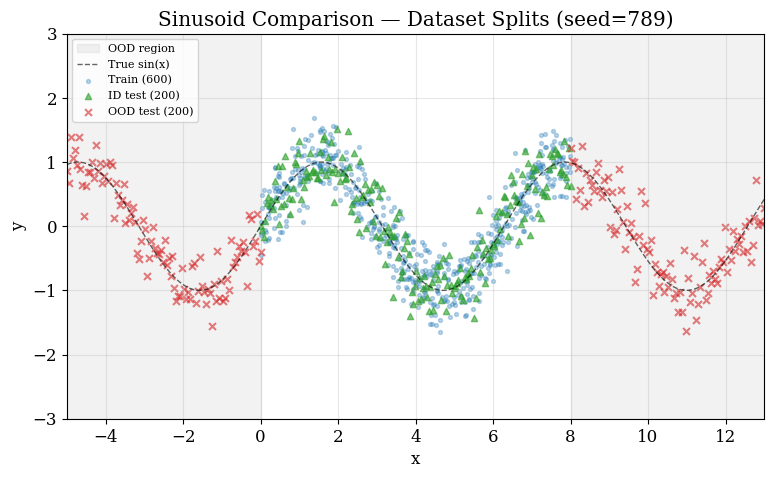

In [5]:
# Dataset visualization (last seed's data as reference)
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10, label="OOD region")
ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
ax.scatter(X_train_np, y_train_np, c="tab:blue", s=8, alpha=0.3, label="Train (600)")
ax.scatter(X_test_id_ref.cpu().flatten().numpy(), y_test_id_np, c="tab:green", marker="^", s=20,
           alpha=0.6, label="ID test (200)")
ax.scatter(X_test_ood_ref.cpu().flatten().numpy(), y_test_ood_np, c="tab:red", marker="x", s=25,
           alpha=0.6, label="OOD test (200)")
ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(f"Sinusoid Comparison — Dataset Splits (seed={SEEDS[-1]})")
ax.legend(loc="upper left", fontsize=8); ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(FIGURES_DIR, "sinusoid_comparison_dataset.png"), dpi=150, bbox_inches="tight")
plt.show()

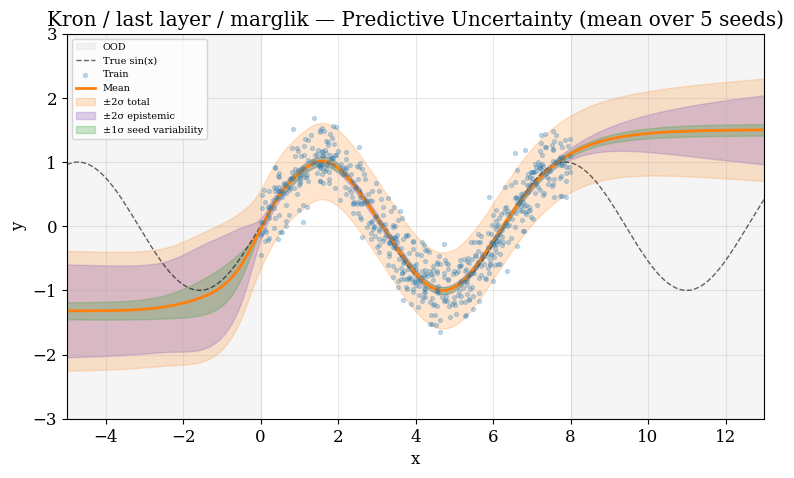

  Saved: sinusoid_comparison_kron_last_layer_marglik_prediction.png


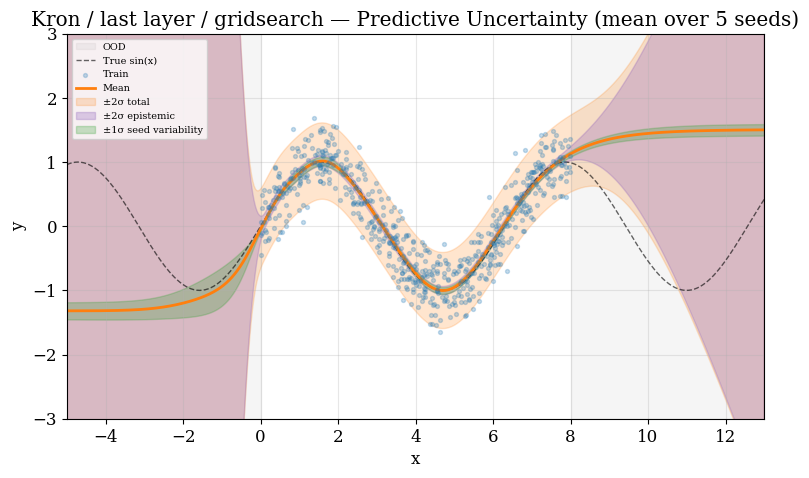

  Saved: sinusoid_comparison_kron_last_layer_gridsearch_prediction.png


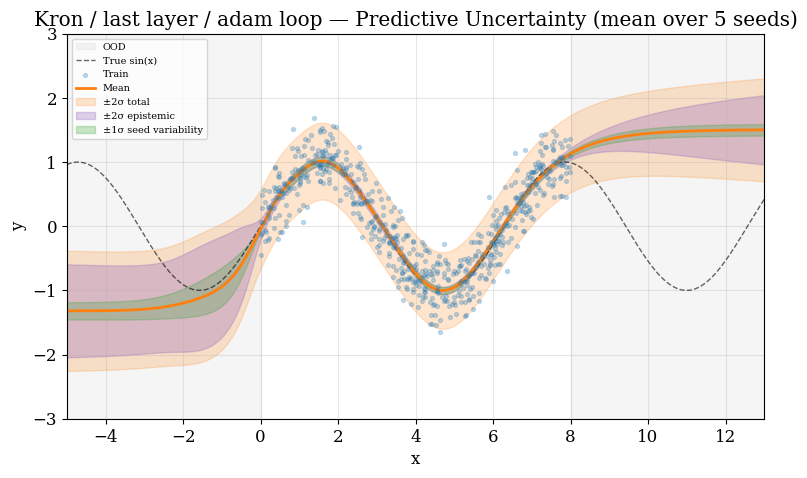

  Saved: sinusoid_comparison_kron_last_layer_adam_loop_prediction.png


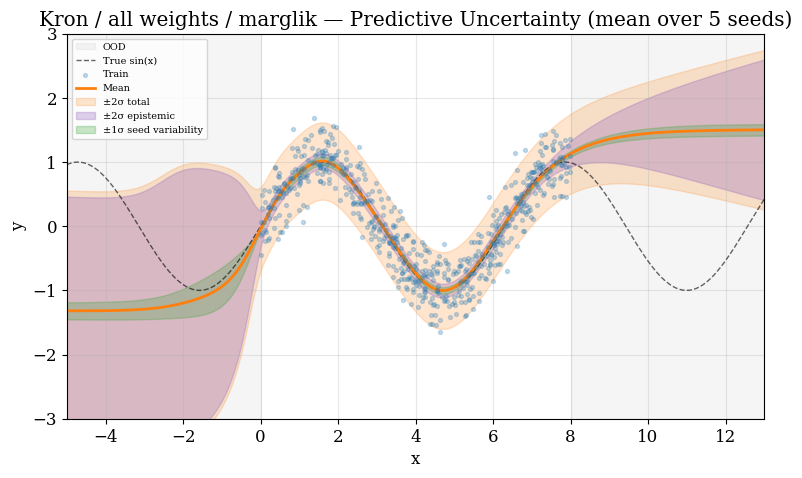

  Saved: sinusoid_comparison_kron_all_marglik_prediction.png


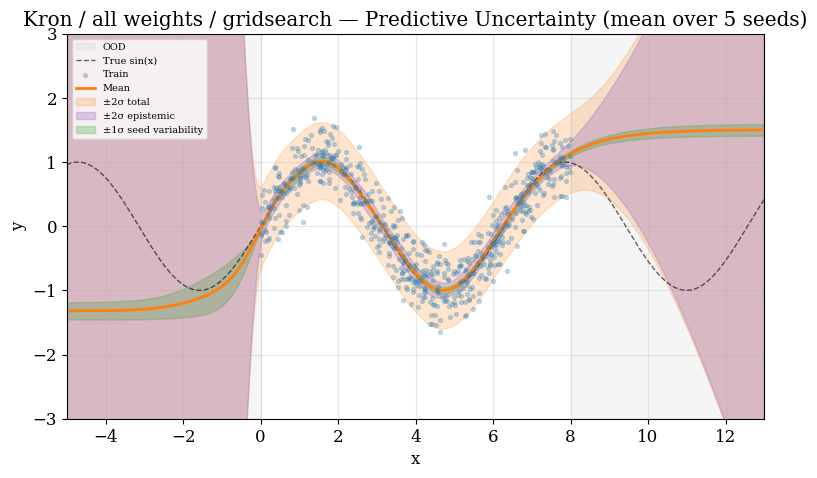

  Saved: sinusoid_comparison_kron_all_gridsearch_prediction.png


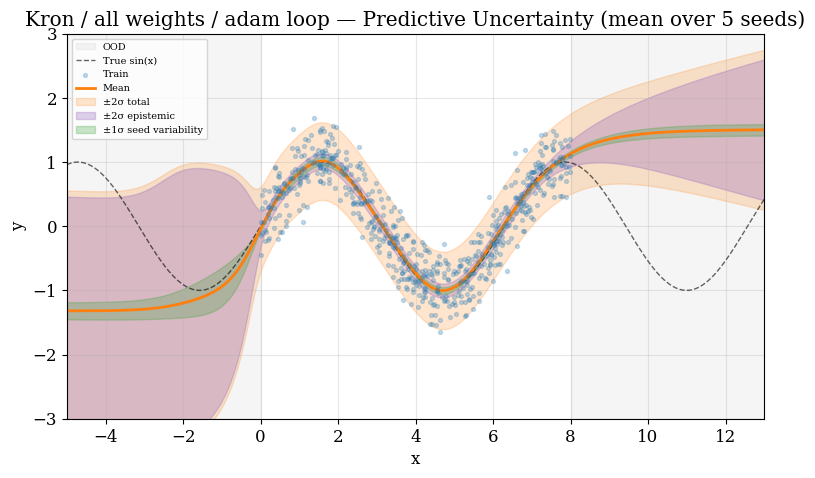

  Saved: sinusoid_comparison_kron_all_adam_loop_prediction.png


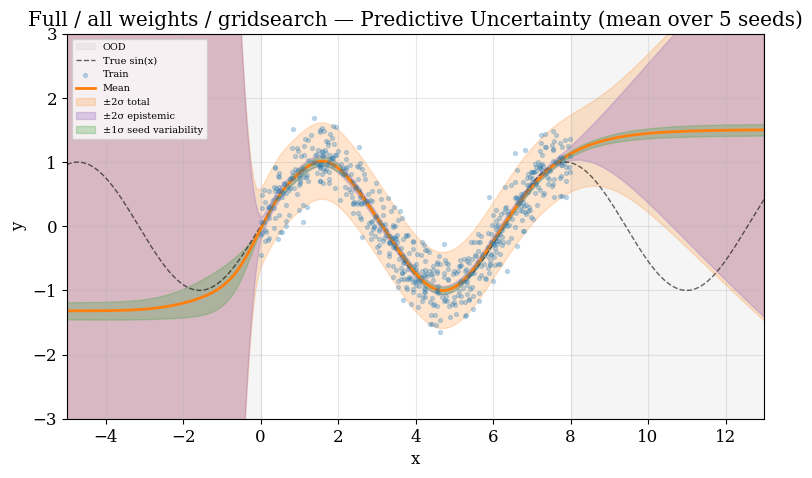

  Saved: sinusoid_comparison_full_all_gridsearch_prediction.png


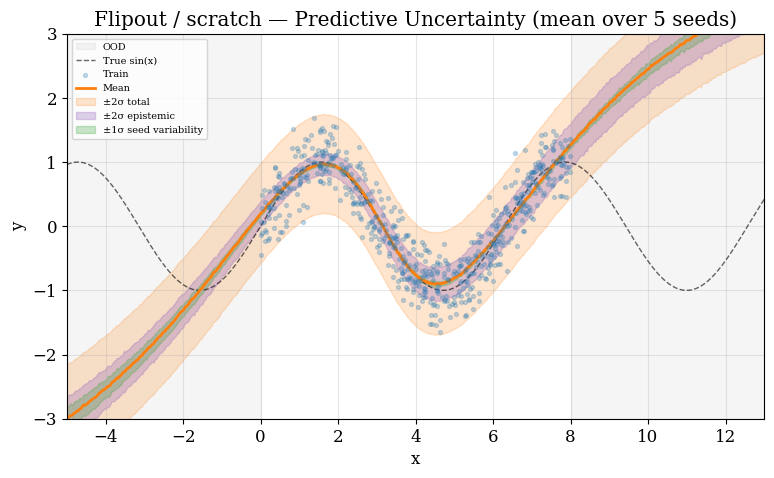

  Saved: sinusoid_comparison_flipout_scratch_prediction.png


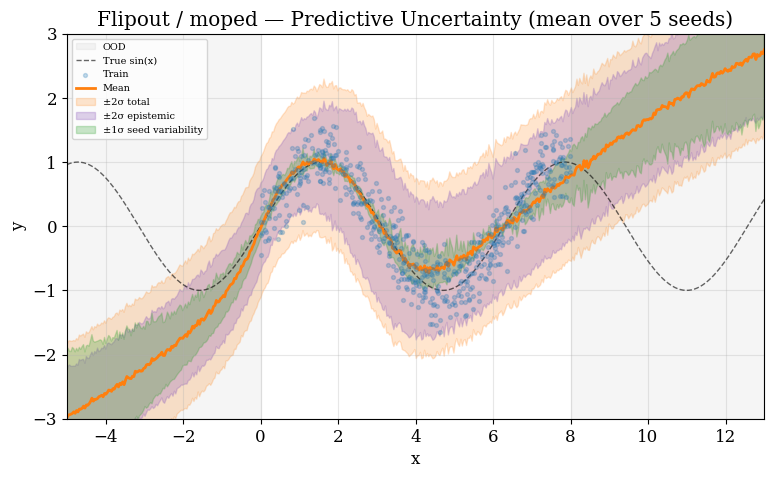

  Saved: sinusoid_comparison_flipout_moped_prediction.png


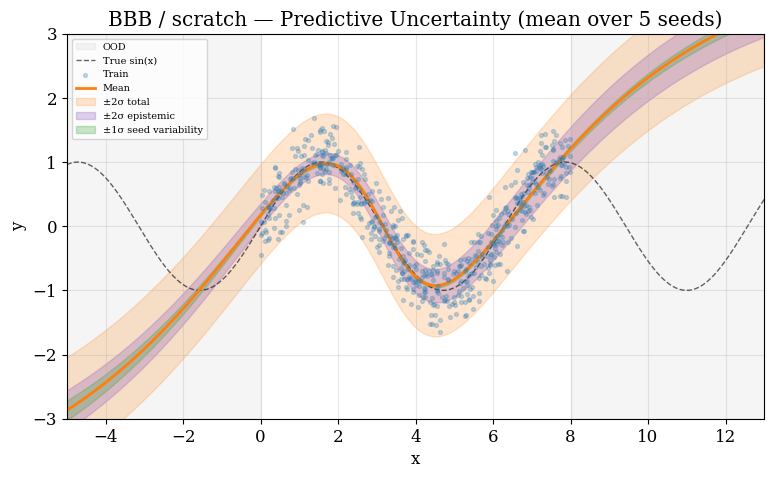

  Saved: sinusoid_comparison_bbb_scratch_prediction.png


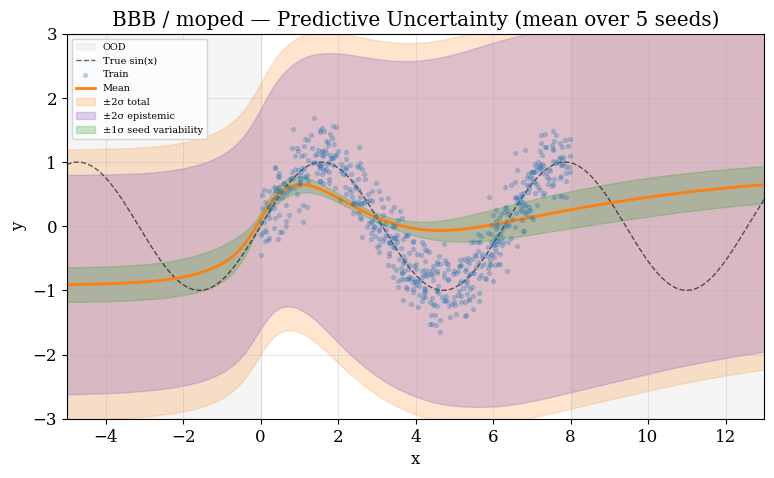

  Saved: sinusoid_comparison_bbb_moped_prediction.png


In [6]:
# Per-variant prediction figures, mean ± seed variability across seeds
all_specs_and_resdict = (
    [(s, all_seed_la_res,  "Laplace", s.get("sigma", sigma_noise)) for s in all_la_specs] +
    [(s, all_seed_bt_res, "BT",      sigma_noise)                  for s in bt_variant_specs]
)

for spec, res_dict, method, aleatoric in all_specs_and_resdict:
    vname = spec["variant_name"]
    f_mus   = np.stack([res_dict[s][vname]["f_mu"]   for s in SEEDS])
    epi_arr = np.stack([res_dict[s][vname]["epi_std"] for s in SEEDS])
    f_mu_mean  = f_mus.mean(0);   std_mu   = f_mus.std(0)
    epi_mean   = epi_arr.mean(0)
    aleatoric = np.mean([res_dict[s][vname]["sigma"] for s in SEEDS])

    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    plot_prediction(x_grid, f_mu_mean, epi_mean, aleatoric,
                    f"{spec['plot_title']} — Predictive Uncertainty (mean over {len(SEEDS)} seeds)",
                    ax, X_train_np, y_train_np)
    ax.fill_between(x_grid, f_mu_mean - std_mu, f_mu_mean + std_mu,
                    color="tab:green", alpha=0.25, label="±1σ seed variability")
    ax.legend(loc="upper left", fontsize=7)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_comparison_{vname}_prediction.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: sinusoid_comparison_{vname}_prediction.png")

In [7]:
# ID vs OOD metrics, mean ± std across seeds
ood_rows, ood_labels = [], []

def ood_row(res_dict, vname, is_la):
    per_seed = [res_dict[s][vname] for s in SEEDS]
    epi_id_vals  = [r["epi_id"].mean()  for r in per_seed]
    epi_ood_vals = [r["epi_ood"].mean() for r in per_seed]
    sigma_vals   = [r["sigma"] for r in per_seed]
    id_rmse_vals, ood_rmse_vals = [], []
    id_nll_vals,  ood_nll_vals  = [], []
    for r, sig, s in zip(per_seed, sigma_vals, SEEDS):
        y_id, y_ood = all_seed_y_test[s]["id"], all_seed_y_test[s]["ood"]
        m_id  = regression_metrics(y_id,  r["mu_id"],  combine_predictive_std(r["epi_id"], sig))
        m_ood = regression_metrics(y_ood, r["mu_ood"], combine_predictive_std(r["epi_ood"], sig))
        id_rmse_vals.append(m_id["RMSE"]); ood_rmse_vals.append(m_ood["RMSE"])
        id_nll_vals.append(m_id["NLL"]);   ood_nll_vals.append(m_ood["NLL"])
    ratio_vals = [ood / (id_ + 1e-12) for id_, ood in zip(epi_id_vals, epi_ood_vals)]
    def pm(vals): return f"{np.mean(vals):.4f} ± {np.std(vals):.4f}"
    return {
        "Method":    "Laplace" if is_la else "BT",
        "ID RMSE":   pm(id_rmse_vals),   "OOD RMSE":  pm(ood_rmse_vals),
        "ID NLL":    pm(id_nll_vals),    "OOD NLL":   pm(ood_nll_vals),
        "ID Epi":    pm(epi_id_vals),    "OOD Epi":   pm(epi_ood_vals),
        "Epi Ratio": pm(ratio_vals),
    }

for spec in all_la_specs:
    ood_rows.append(ood_row(all_seed_la_res, spec["variant_name"], is_la=True))
    ood_labels.append(spec["plot_title"])
for spec in bt_variant_specs:
    ood_rows.append(ood_row(all_seed_bt_res, spec["variant_name"], is_la=False))
    ood_labels.append(spec["plot_title"])

ood_df = pd.DataFrame(ood_rows, index=ood_labels); ood_df.index.name = "Variant"
print("ID vs OOD — mean ± std (5 seeds)")
display(ood_df)
ood_df.to_csv("results/metrics/sinusoid_comparison_5seed_ood_metrics.csv")
print("Saved to results/metrics/sinusoid_comparison_5seed_ood_metrics.csv")

ID vs OOD — mean ± std (5 seeds)


,Method,ID RMSE,OOD RMSE,ID NLL,OOD NLL,ID Epi,OOD Epi,Epi Ratio
Variant,,,,,,,,
Kron / last layer / marglik,Laplace,0.3092 ± 0.0091,1.5835 ± 0.0746,0.2470 ± 0.0309,9.1123 ± 2.4392,0.0347 ± 0.0011,0.2545 ± 0.0803,7.2859 ± 2.1400
Kron / last layer / gridsearch,Laplace,0.3092 ± 0.0091,1.5835 ± 0.0746,0.2465 ± 0.0309,7.3456 ± 5.0446,0.0371 ± 0.0103,3.6582 ± 4.8028,77.1485 ± 97.7799
Kron / last layer / adam loop,Laplace,0.3092 ± 0.0091,1.5835 ± 0.0746,0.2463 ± 0.0305,9.0230 ± 2.4164,0.0349 ± 0.0012,0.2551 ± 0.0806,7.2568 ± 2.1340
Kron / all weights / marglik,Laplace,0.3092 ± 0.0091,1.5835 ± 0.0746,0.2460 ± 0.0306,5.4179 ± 1.8295,0.0598 ± 0.0019,0.5933 ± 0.2374,9.8395 ± 3.7229
Kron / all weights / gridsearch,Laplace,0.3092 ± 0.0091,1.5835 ± 0.0746,0.2454 ± 0.0308,7.1534 ± 4.9226,0.0625 ± 0.0233,3.8675 ± 5.0938,47.5671 ± 63.8736
Kron / all weights / adam loop,Laplace,0.3092 ± 0.0091,1.5835 ± 0.0746,0.2455 ± 0.0303,5.3720 ± 1.8053,0.0602 ± 0.0020,0.5938 ± 0.2362,9.7925 ± 3.6938
Full / all weights / gridsearch,Laplace,0.3092 ± 0.0091,1.5835 ± 0.0746,0.2466 ± 0.0310,7.5302 ± 4.8818,0.0369 ± 0.0106,4.1296 ± 5.1526,87.6212 ± 107.9210
Flipout / scratch,BT,0.3198 ± 0.0060,2.6134 ± 0.0796,0.3192 ± 0.0149,20.0801 ± 1.5751,0.1216 ± 0.0191,0.1519 ± 0.0210,1.2615 ± 0.1612
Flipout / moped,BT,0.3983 ± 0.1055,2.2729 ± 0.5762,0.5886 ± 0.3236,11.6601 ± 6.1422,0.4156 ± 0.3253,0.4158 ± 0.2123,1.1780 ± 0.4378


Saved to results/metrics/sinusoid_comparison_5seed_ood_metrics.csv


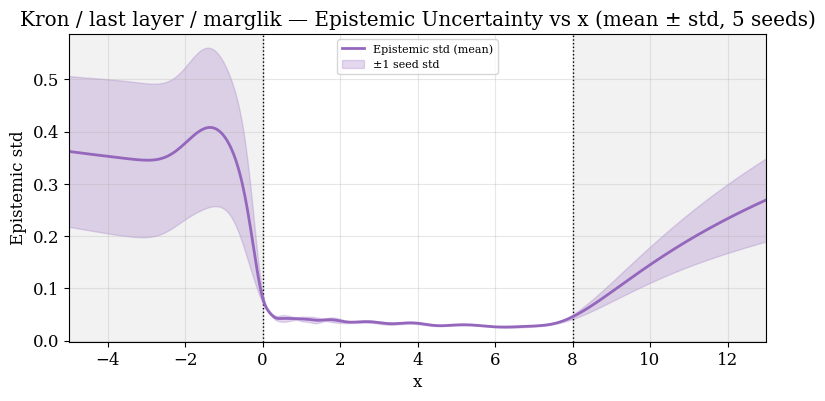

  Saved: sinusoid_comparison_kron_last_layer_marglik_ood_epistemic.png


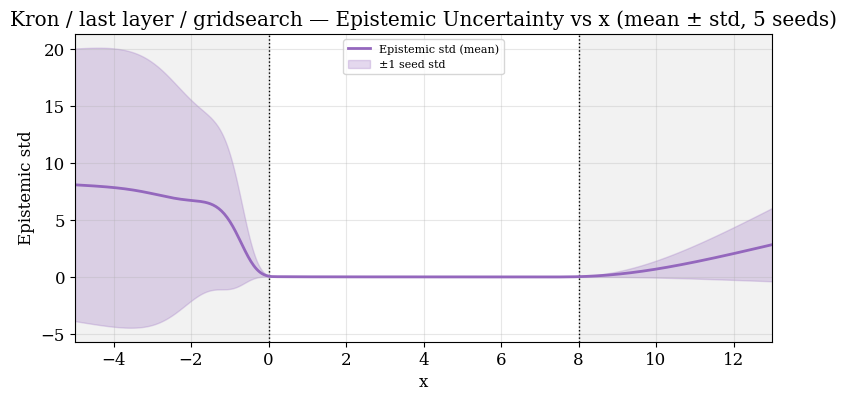

  Saved: sinusoid_comparison_kron_last_layer_gridsearch_ood_epistemic.png


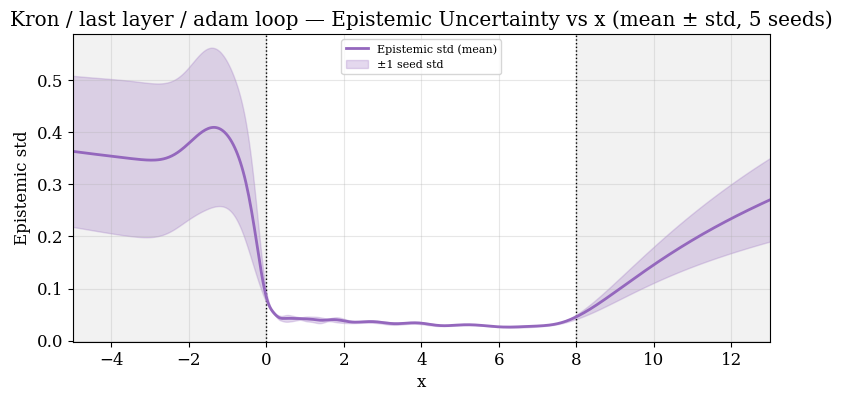

  Saved: sinusoid_comparison_kron_last_layer_adam_loop_ood_epistemic.png


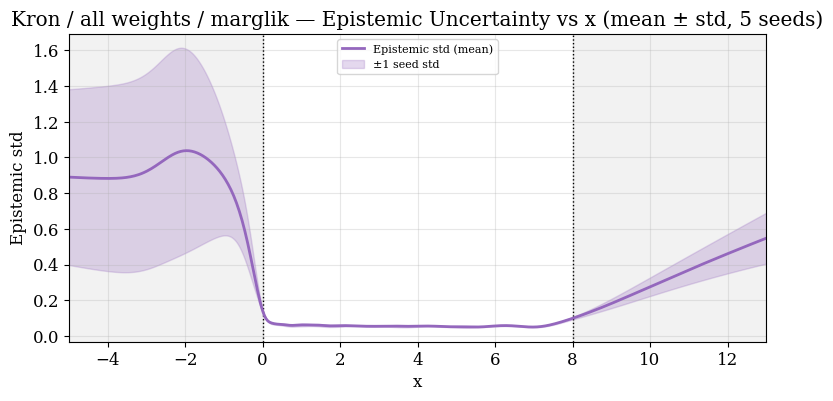

  Saved: sinusoid_comparison_kron_all_marglik_ood_epistemic.png


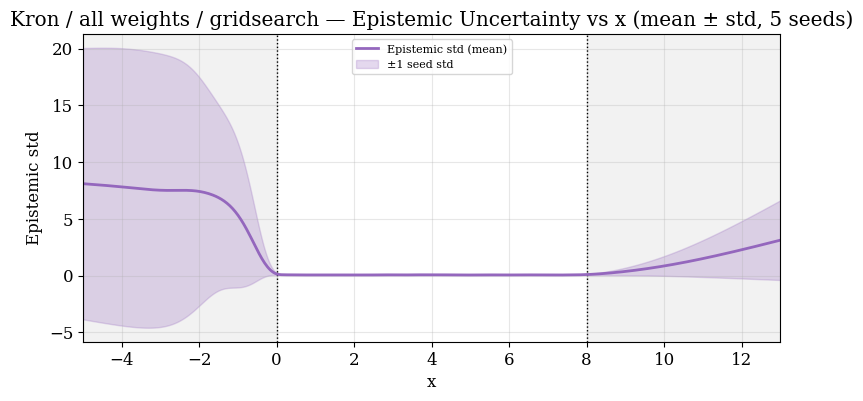

  Saved: sinusoid_comparison_kron_all_gridsearch_ood_epistemic.png


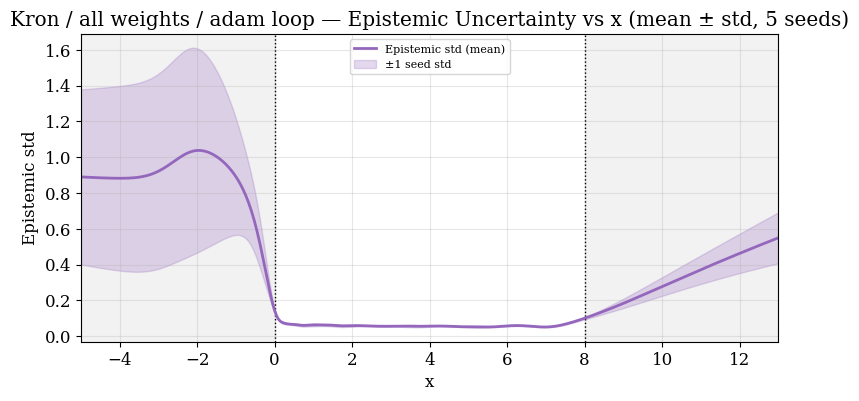

  Saved: sinusoid_comparison_kron_all_adam_loop_ood_epistemic.png


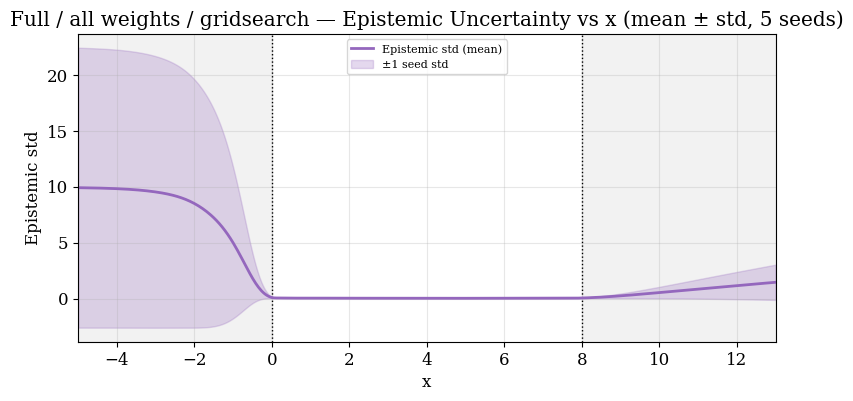

  Saved: sinusoid_comparison_full_all_gridsearch_ood_epistemic.png


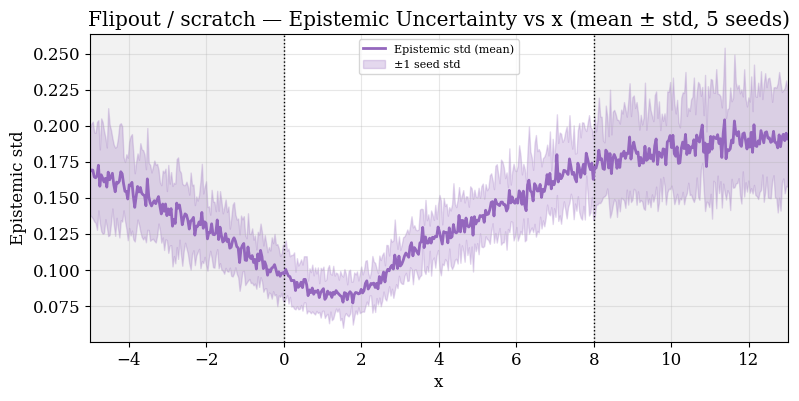

  Saved: sinusoid_comparison_flipout_scratch_ood_epistemic.png


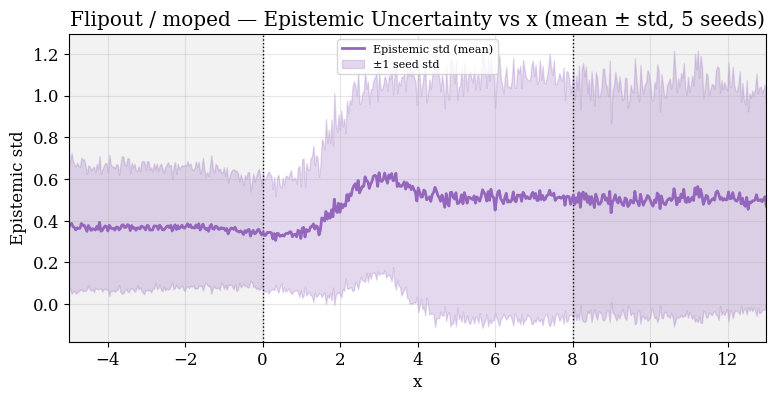

  Saved: sinusoid_comparison_flipout_moped_ood_epistemic.png


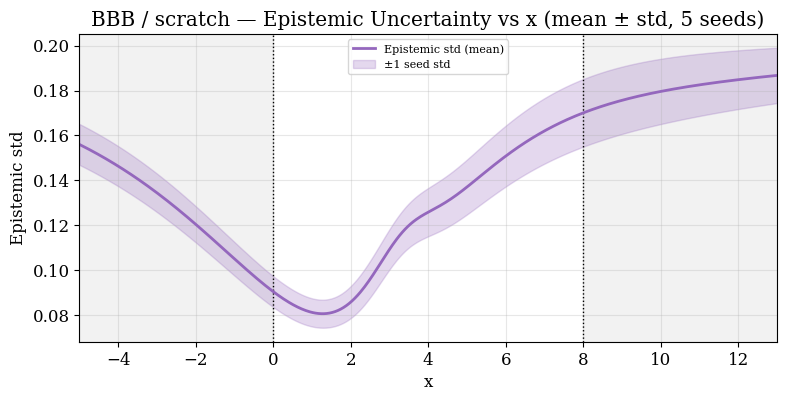

  Saved: sinusoid_comparison_bbb_scratch_ood_epistemic.png


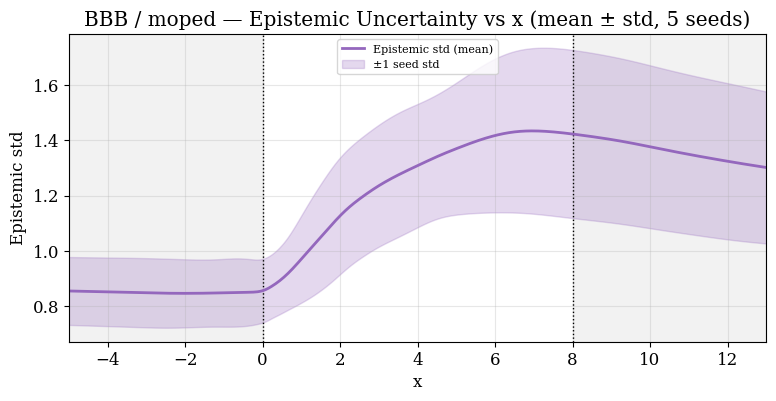

  Saved: sinusoid_comparison_bbb_moped_ood_epistemic.png


In [8]:
# OOD epistemic uncertainty figures, mean ± std across seeds
for spec, res_dict, method, _ in all_specs_and_resdict:
    vname = spec["variant_name"]
    epi_arr = np.stack([res_dict[s][vname]["epi_std"] for s in SEEDS])
    epi_mean = epi_arr.mean(0); epi_std_ = epi_arr.std(0)

    fig, ax = plt.subplots(1, 1, figsize=(9, 4))
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10)
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
    ax.axvline(TRAIN_LO, color="k", ls=":", lw=1)
    ax.axvline(TRAIN_HI, color="k", ls=":", lw=1)
    ax.plot(x_grid, epi_mean, color="tab:purple", lw=2, label="Epistemic std (mean)")
    ax.fill_between(x_grid, epi_mean - epi_std_, epi_mean + epi_std_,
                    color="tab:purple", alpha=0.25, label="±1 seed std")
    ax.set_xlim(-5, 13)
    ax.set_xlabel("x"); ax.set_ylabel("Epistemic std")
    ax.set_title(f"{spec['plot_title']} — Epistemic Uncertainty vs x (mean ± std, {len(SEEDS)} seeds)")
    ax.legend(loc="upper center", fontsize=8); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_comparison_{vname}_ood_epistemic.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: sinusoid_comparison_{vname}_ood_epistemic.png")


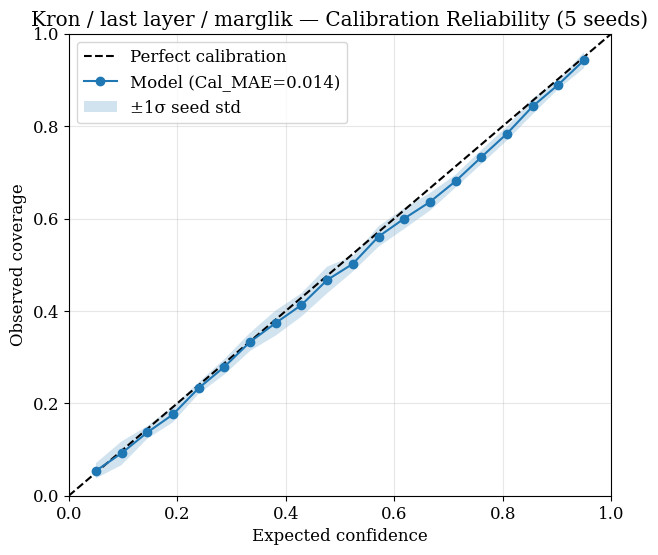

  Saved: sinusoid_comparison_kron_last_layer_marglik_calibration.png


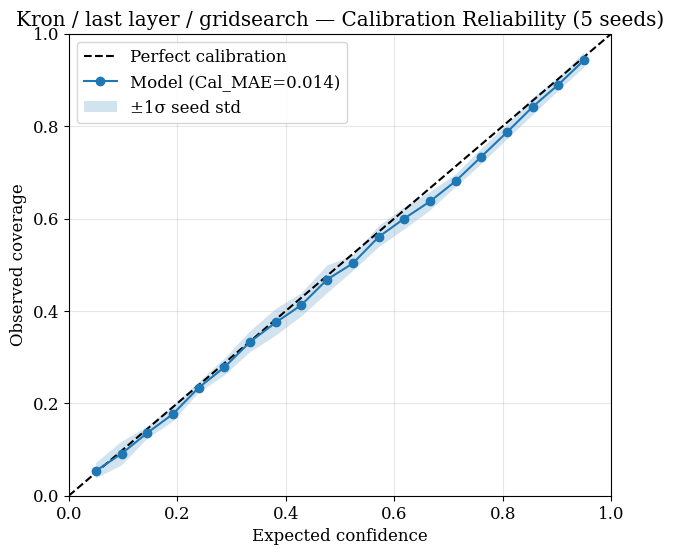

  Saved: sinusoid_comparison_kron_last_layer_gridsearch_calibration.png


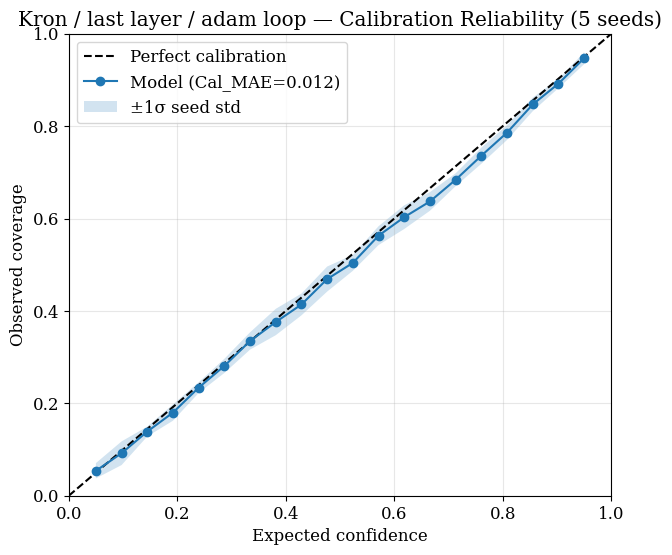

  Saved: sinusoid_comparison_kron_last_layer_adam_loop_calibration.png


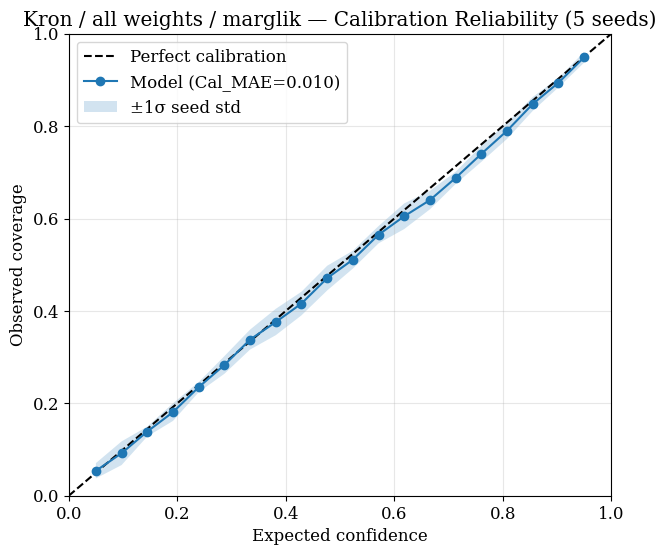

  Saved: sinusoid_comparison_kron_all_marglik_calibration.png


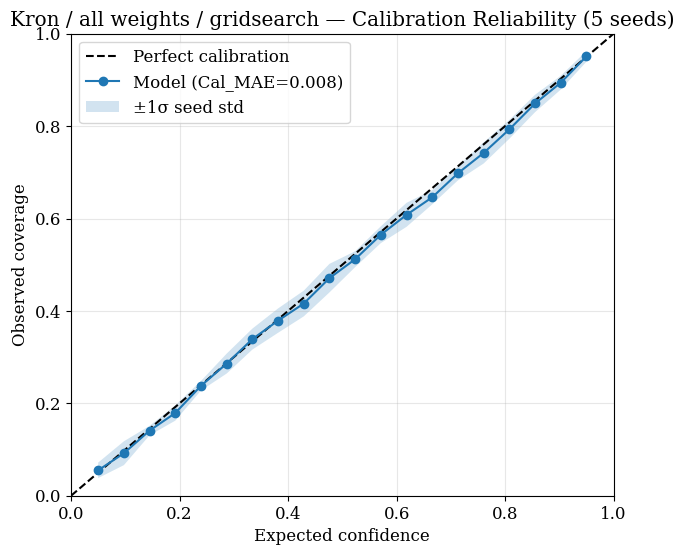

  Saved: sinusoid_comparison_kron_all_gridsearch_calibration.png


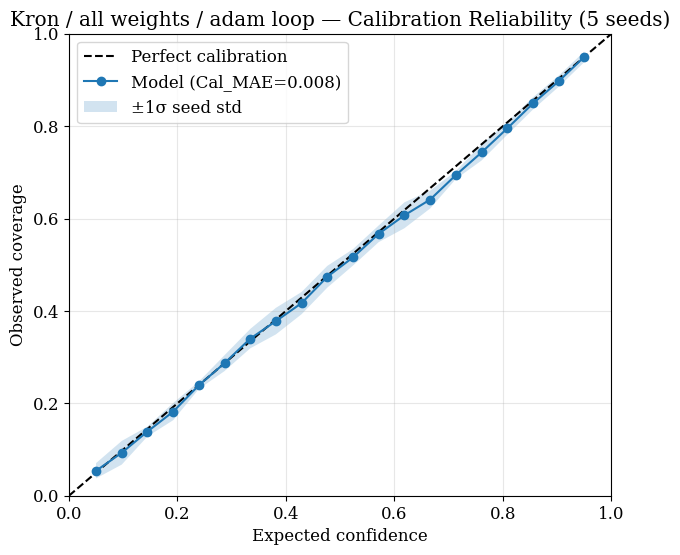

  Saved: sinusoid_comparison_kron_all_adam_loop_calibration.png


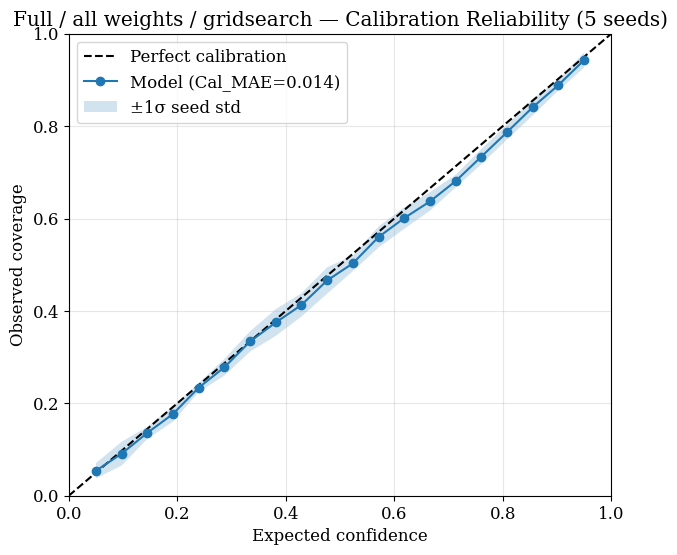

  Saved: sinusoid_comparison_full_all_gridsearch_calibration.png


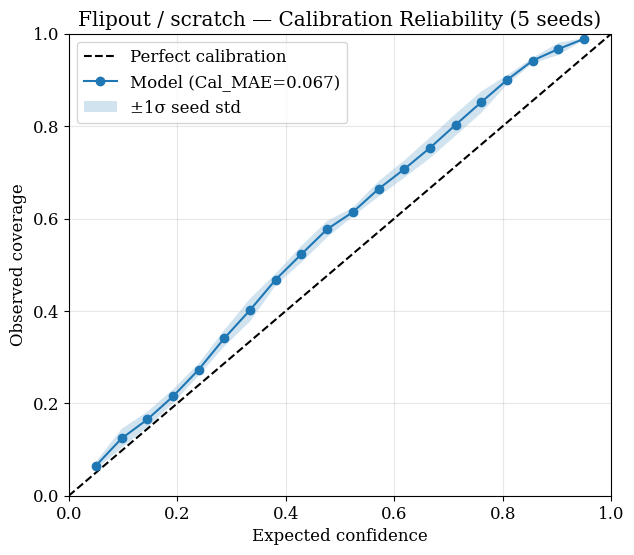

  Saved: sinusoid_comparison_flipout_scratch_calibration.png


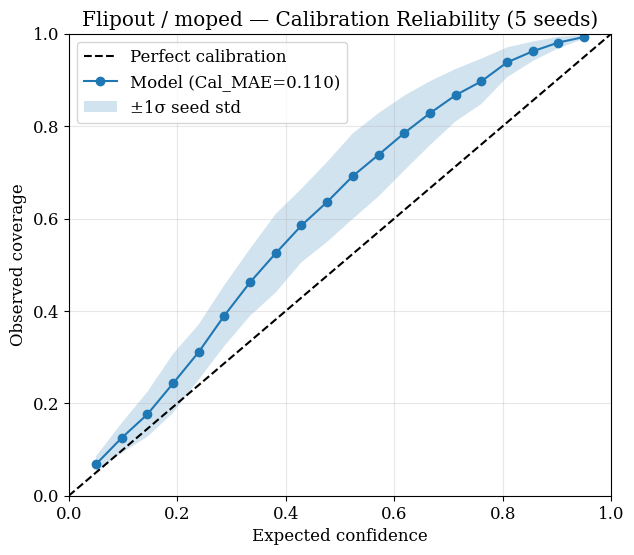

  Saved: sinusoid_comparison_flipout_moped_calibration.png


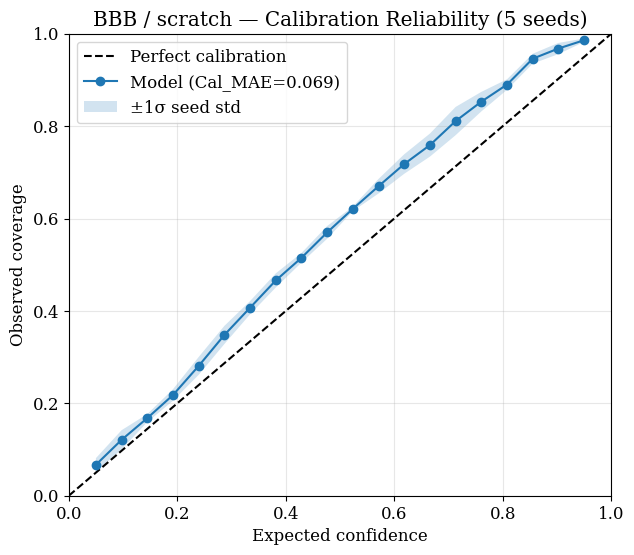

  Saved: sinusoid_comparison_bbb_scratch_calibration.png


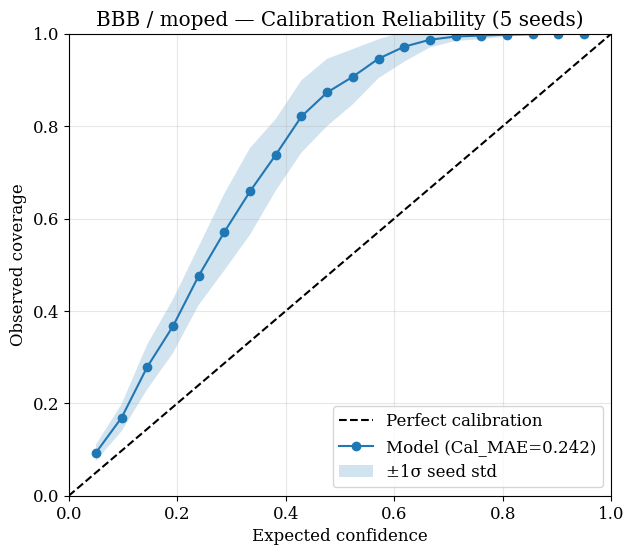

  Saved: sinusoid_comparison_bbb_moped_calibration.png


In [9]:
# Calibration reliability diagrams, mean ± std band across seeds
conf_levels = np.linspace(0.05, 0.95, 20)

def compute_coverage(mu, sigma_total, y_true):
    z = np.abs((y_true - mu) / np.clip(sigma_total, 1e-12, None))
    return np.array([float(np.mean(z <= _norm.ppf((1+c)/2))) for c in conf_levels])

for spec, res_dict, method, _ in all_specs_and_resdict:
    vname = spec["variant_name"]
    curves = []
    for s in SEEDS:
        r = res_dict[s][vname]
        sig = r["sigma"]
        total_id = combine_predictive_std(r["epi_id"], sig)
        curves.append(compute_coverage(r["mu_id"], total_id, all_seed_y_test[s]["id"]))
    curves = np.stack(curves)
    mean_cov = curves.mean(0); std_cov = curves.std(0)
    cal_mae  = float(np.mean(np.abs(mean_cov - conf_levels)))

    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(conf_levels, mean_cov, "o-", label=f"Model (Cal_MAE={cal_mae:.3f})")
    ax.fill_between(conf_levels, mean_cov - std_cov, mean_cov + std_cov,
                    alpha=0.2, label="±1σ seed std")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Expected confidence"); ax.set_ylabel("Observed coverage")
    ax.set_title(f"{spec['plot_title']} — Calibration Reliability ({len(SEEDS)} seeds)")
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_comparison_{vname}_calibration.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: sinusoid_comparison_{vname}_calibration.png")

# MOPED delta sweep: δ ∈ {0.05, 0.1, 0.2}

The original paper (Krishnan et al. 2020) only validated δ ∈ {0.05, 0.1, 0.2} on classification.
Our δ=0.5 (copied from the bayesian-torch README example) is 2.5× above the paper's maximum.
Here we retrain Flipout/MOPED and BBB/MOPED across the paper's range, averaged over 5 seeds.

In [10]:
# Delta sweep, comparison table (mean ± std across seeds)
ref_variants = [
    ("flipout_scratch", "Flipout / scratch (ref)"),
    ("flipout_moped",   "Flipout / moped / δ=0.5"),
    ("bbb_scratch",     "BBB / scratch (ref)"),
    ("bbb_moped",       "BBB / moped / δ=0.5"),
]

def _delta_row(res_dict_per_seed, vname):
    per_seed = [res_dict_per_seed[s][vname] for s in SEEDS]
    epi_id_vals  = [r["epi_id"].mean()  for r in per_seed]
    epi_ood_vals = [r["epi_ood"].mean() for r in per_seed]
    id_vals  = [regression_metrics(all_seed_y_test[s]["id"],  r["mu_id"],  combine_predictive_std(r["epi_id"], r["sigma"])) for r, s in zip(per_seed, SEEDS)]
    ood_vals = [regression_metrics(all_seed_y_test[s]["ood"], r["mu_ood"], combine_predictive_std(r["epi_ood"], r["sigma"])) for r, s in zip(per_seed, SEEDS)]
    ratio_vals = [ood / (id_ + 1e-12) for id_, ood in zip(epi_id_vals, epi_ood_vals)]
    epoch_vals = [r["metrics"].get("Epochs", float("nan")) for r in per_seed]
    def pm(vals): return f"{np.mean(vals):.4f} ± {np.std(vals):.4f}"
    return {
        "ID RMSE":    pm([m["RMSE"] for m in id_vals]),
        "ID NLL":     pm([m["NLL"]  for m in id_vals]),
        "ID Cal Error": pm([r["metrics"].get("Calibration_Error", float("nan")) for r in per_seed]),
        "ID Epi":     pm(epi_id_vals),
        "OOD RMSE":   pm([m["RMSE"] for m in ood_vals]),
        "OOD NLL":    pm([m["NLL"]  for m in ood_vals]),
        "OOD Epi":    pm(epi_ood_vals),
        "Epi Ratio":  pm(ratio_vals),
        "Epochs":     f"{int(round(np.mean(epoch_vals)))} ± {int(round(np.std(epoch_vals)))}",
    }

rows, labels = [], []
for vname, label in ref_variants:
    rows.append(_delta_row(all_seed_bt_res, vname)); labels.append(label)
for spec in delta_variant_specs:
    rows.append(_delta_row(all_seed_delta_res, spec["variant_name"])); labels.append(spec["plot_title"])

cmp_df = pd.DataFrame(rows, index=labels); cmp_df.index.name = "Variant"
print("MOPED delta sweep — mean ± std (5 seeds)")
display(cmp_df)
cmp_df.to_csv("results/metrics/sinusoid_delta_sweep_5seed_metrics.csv")
print("Saved to results/metrics/sinusoid_delta_sweep_5seed_metrics.csv")

MOPED delta sweep — mean ± std (5 seeds)


,ID RMSE,ID NLL,ID Cal Error,ID Epi,OOD RMSE,OOD NLL,OOD Epi,Epi Ratio,Epochs
Variant,,,,,,,,,
Flipout / scratch (ref),0.3198 ± 0.0060,0.3192 ± 0.0149,0.5196 ± 0.3337,0.1216 ± 0.0191,2.6134 ± 0.0796,20.0801 ± 1.5751,0.1519 ± 0.0210,1.2615 ± 0.1612,528 ± 66
Flipout / moped / δ=0.5,0.3983 ± 0.1055,0.5886 ± 0.3236,1.2034 ± 1.3206,0.4156 ± 0.3253,2.2729 ± 0.5762,11.6601 ± 6.1422,0.4158 ± 0.2123,1.1780 ± 0.4378,341 ± 118
BBB / scratch (ref),0.3161 ± 0.0054,0.3104 ± 0.0105,0.4544 ± 0.3180,0.1176 ± 0.0088,2.5112 ± 0.0613,18.8684 ± 0.9010,0.1441 ± 0.0130,1.2267 ± 0.0773,991 ± 19
BBB / moped / δ=0.5,0.6037 ± 0.0181,1.3395 ± 0.1041,3.4563 ± 1.0488,1.2654 ± 0.1899,1.0325 ± 0.0386,1.5134 ± 0.0543,1.1266 ± 0.1523,0.8939 ± 0.0530,126 ± 34
Flipout / moped / δ=0.05,0.3074 ± 0.0083,0.3018 ± 0.0291,0.5283 ± 0.1330,0.1309 ± 0.0311,1.5387 ± 0.0728,7.9388 ± 0.9474,0.0879 ± 0.0265,0.7114 ± 0.2793,111 ± 22
Flipout / moped / δ=0.1,0.3162 ± 0.0150,0.3559 ± 0.0787,0.8274 ± 0.2785,0.2017 ± 0.1004,1.6741 ± 0.1464,8.9822 ± 1.8774,0.1283 ± 0.0378,0.7695 ± 0.3152,210 ± 122
Flipout / moped / δ=0.2,0.3204 ± 0.0143,0.3583 ± 0.0771,0.5687 ± 0.2179,0.1955 ± 0.0895,2.3240 ± 0.3835,15.9691 ± 5.6200,0.1806 ± 0.0848,0.9659 ± 0.3349,344 ± 89
BBB / moped / δ=0.05,0.3089 ± 0.0094,0.3297 ± 0.0188,0.7903 ± 0.2615,0.1852 ± 0.0231,1.5444 ± 0.0768,7.9634 ± 0.8143,0.0934 ± 0.0103,0.5055 ± 0.0194,112 ± 27
BBB / moped / δ=0.1,0.3222 ± 0.0123,0.4295 ± 0.0595,1.4195 ± 0.4989,0.3123 ± 0.0648,1.5388 ± 0.0774,6.9677 ± 0.5786,0.1737 ± 0.0274,0.5661 ± 0.0549,161 ± 94


Saved to results/metrics/sinusoid_delta_sweep_5seed_metrics.csv


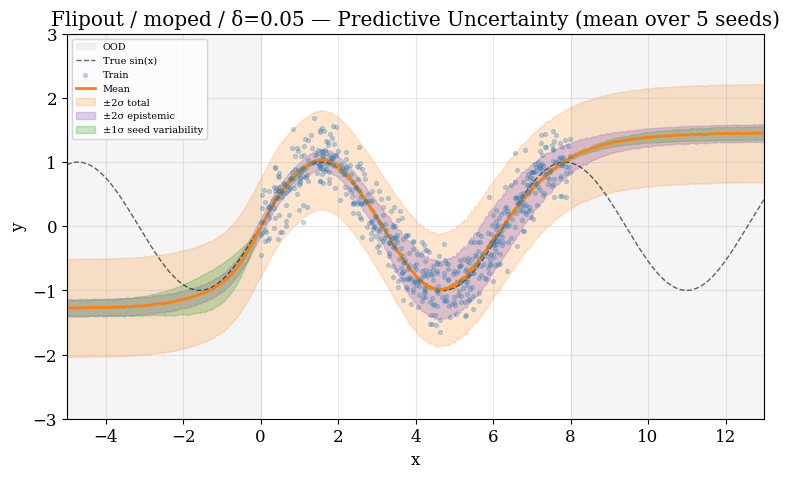

  Saved: sinusoid_comparison_flipout_moped_d005_prediction.png


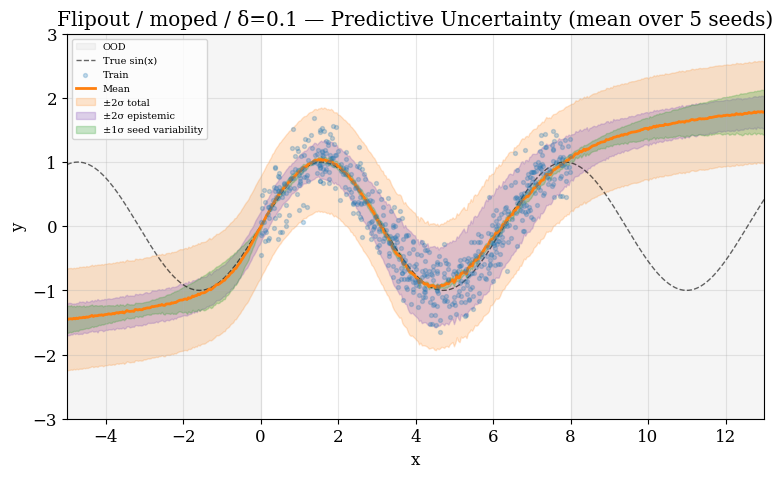

  Saved: sinusoid_comparison_flipout_moped_d01_prediction.png


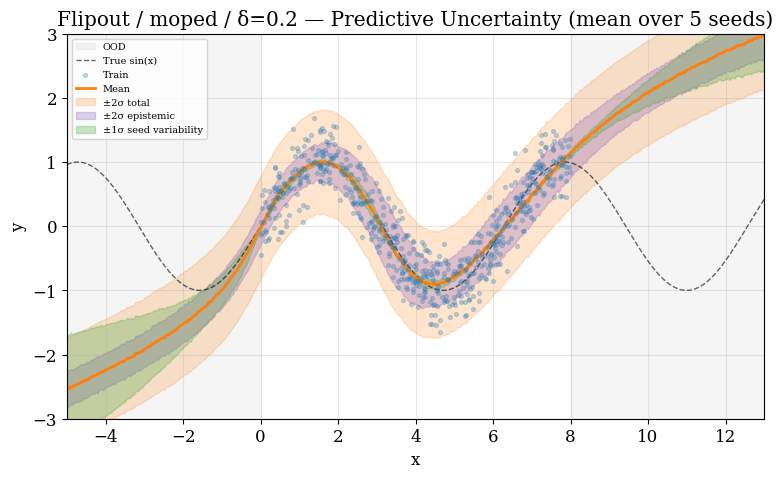

  Saved: sinusoid_comparison_flipout_moped_d02_prediction.png


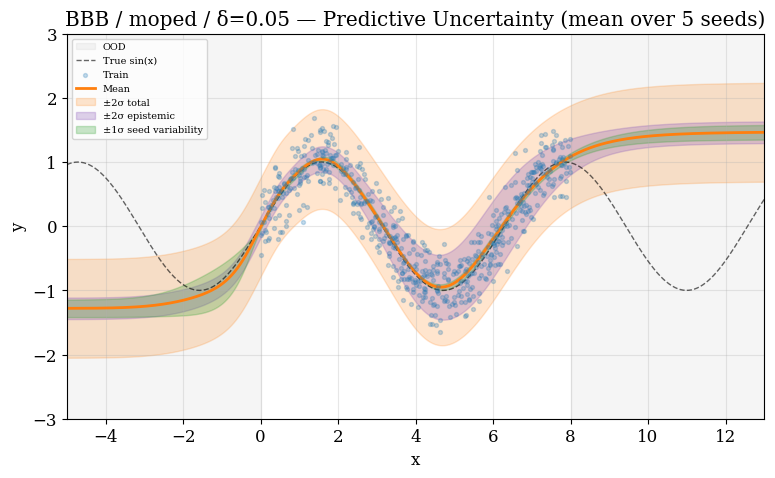

  Saved: sinusoid_comparison_bbb_moped_d005_prediction.png


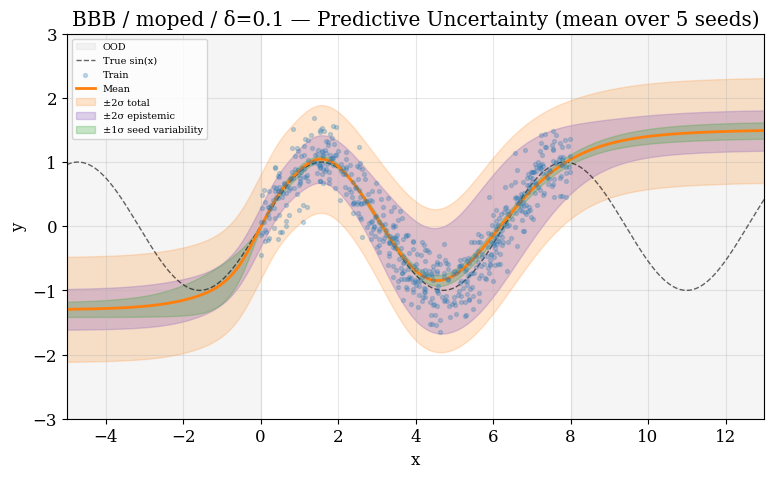

  Saved: sinusoid_comparison_bbb_moped_d01_prediction.png


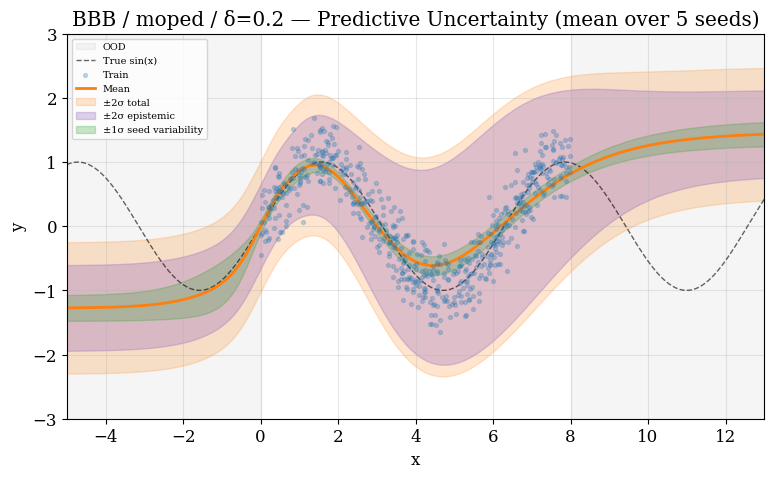

  Saved: sinusoid_comparison_bbb_moped_d02_prediction.png


In [11]:
# Delta sweep, prediction plots (mean ± seed variability across seeds)
for spec in delta_variant_specs:
    vname = spec["variant_name"]
    f_mus   = np.stack([all_seed_delta_res[s][vname]["f_mu"]   for s in SEEDS])
    epi_arr = np.stack([all_seed_delta_res[s][vname]["epi_std"] for s in SEEDS])
    f_mu_mean = f_mus.mean(0); std_mu = f_mus.std(0)
    mean_sigma = np.mean([all_seed_delta_res[s][vname]["sigma"] for s in SEEDS])
    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    plot_prediction(x_grid, f_mu_mean, epi_arr.mean(0), mean_sigma,
                    f"{spec['plot_title']} — Predictive Uncertainty (mean over {len(SEEDS)} seeds)",
                    ax, X_train_np, y_train_np)
    ax.fill_between(x_grid, f_mu_mean - std_mu, f_mu_mean + std_mu,
                    color="tab:green", alpha=0.25, label="±1σ seed variability")
    ax.legend(loc="upper left", fontsize=7)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_comparison_{vname}_prediction.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: sinusoid_comparison_{vname}_prediction.png")

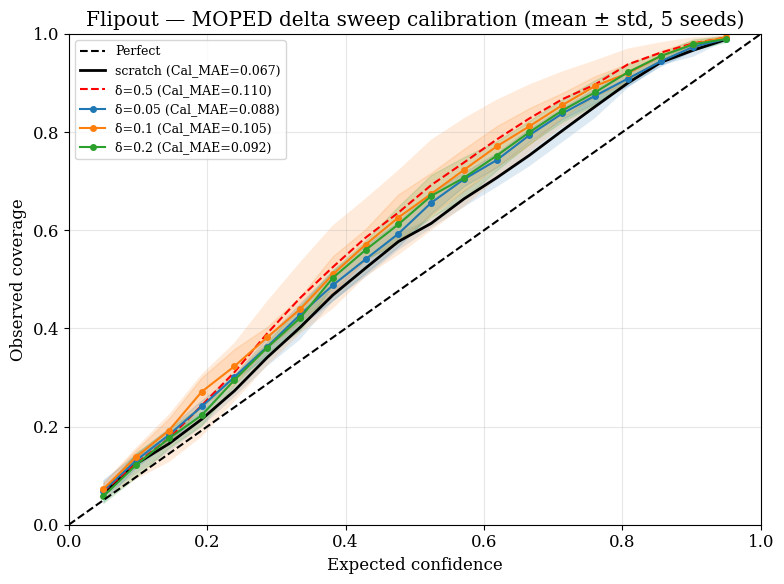

Saved: sinusoid_flipout_moped_delta_calibration.png


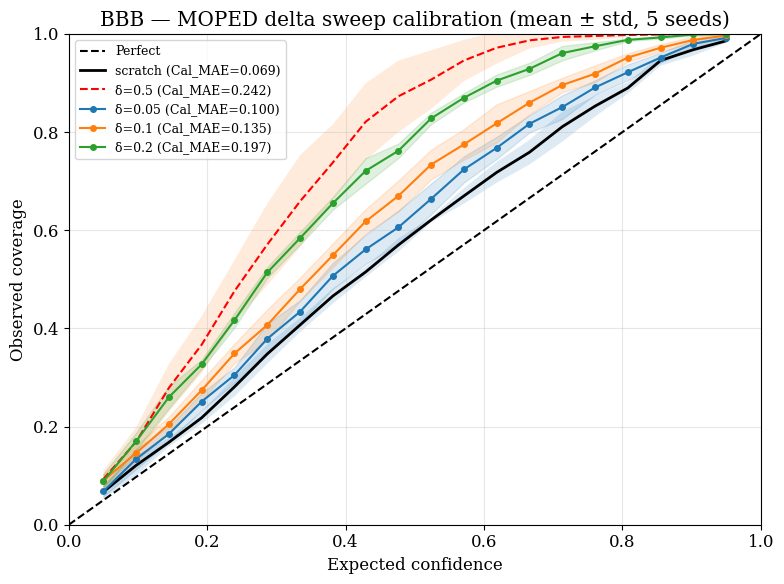

Saved: sinusoid_bbb_moped_delta_calibration.png


In [12]:
# Combined calibration plot: scratch + all MOPED deltas (Flipout and BBB separately, mean ± std)
conf_levels = np.linspace(0.05, 0.95, 20)

for model_short, model_type in [("flipout", "Flipout"), ("bbb", "BBB")]:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect", zorder=5)

    for label, res_dict, vname, style in [
        ("scratch",    all_seed_bt_res, f"{model_short}_scratch", ("k-",  2)),
        ("δ=0.5", all_seed_bt_res, f"{model_short}_moped",   ("r--", 1.5)),
    ]:
        curves = []
        for s in SEEDS:
            r = res_dict[s][vname]
            total_id = combine_predictive_std(r["epi_id"], r["sigma"])
            curves.append(compute_coverage(r["mu_id"], total_id, all_seed_y_test[s]["id"]))
        curves = np.stack(curves)
        mean_cov = curves.mean(0); std_cov = curves.std(0)
        cal_mae = float(np.mean(np.abs(mean_cov - conf_levels)))
        ax.plot(conf_levels, mean_cov, style[0], lw=style[1],
                label=f"{label} (Cal_MAE={cal_mae:.3f})")
        ax.fill_between(conf_levels, mean_cov - std_cov, mean_cov + std_cov, alpha=0.15)

    colors_d = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    for spec, color in zip([s for s in delta_variant_specs if model_short in s["variant_name"]], colors_d):
        curves = []
        for s in SEEDS:
            r = all_seed_delta_res[s][spec["variant_name"]]
            total_id = combine_predictive_std(r["epi_id"], r["sigma"])
            curves.append(compute_coverage(r["mu_id"], total_id, all_seed_y_test[s]["id"]))
        curves = np.stack(curves)
        mean_cov = curves.mean(0); std_cov = curves.std(0)
        cal_mae = float(np.mean(np.abs(mean_cov - conf_levels)))
        ax.plot(conf_levels, mean_cov, "o-", color=color, lw=1.5, ms=4,
                label=f"δ={spec['moped_delta']} (Cal_MAE={cal_mae:.3f})")
        ax.fill_between(conf_levels, mean_cov - std_cov, mean_cov + std_cov,
                        color=color, alpha=0.15)

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Expected confidence"); ax.set_ylabel("Observed coverage")
    ax.set_title(f"{model_type} — MOPED delta sweep calibration (mean ± std, {len(SEEDS)} seeds)")
    ax.legend(fontsize=9, loc="upper left"); ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_{model_short}_moped_delta_calibration.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: sinusoid_{model_short}_moped_delta_calibration.png")